In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [2]:
!pip install scikit-image==0.14.2

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 25.3 MB 1.4 MB/s 
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.18.3
    Uninstalling scikit-image-0.18.3:
      Successfully uninstalled scikit-image-0.18.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 1.2.1 requires scikit-image>=0.16.1, but you have scikit-image 0.14.2 which is incompatible.


In [2]:
import os
import math
import numpy as np 
import nibabel as nib
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.ndimage import zoom 
import cv2
import skimage
#from skimage.measure import compare_ssim
from skimage.metrics import structural_similarity as ssim

In [144]:
from scipy.fftpack import dct, idct

In [3]:
skimage.__version__

'0.18.3'

In [4]:
data_path = '/content/gdrive/MyDrive/code/523/data'
os.path.isdir(data_path)

True

In [5]:
groundtruth = nib.load(os.path.join(data_path, "fieldmap_rads_groundtruth.nii")).get_fdata()
mask = nib.load(os.path.join(data_path, "mask.nii")).get_fdata()
snr20 = nib.load(os.path.join(data_path, "t2_snr20_b0space.nii")).get_fdata()
snr40 = nib.load(os.path.join(data_path, "t2_snr40_b0space.nii")).get_fdata()
snrinfinite = nib.load(os.path.join(data_path, "t2_snrinfinite_b0space.nii")).get_fdata()

In [6]:
ma_20=np.max(snr20)
mi_20=np.min(snr20)
n_snr20=255*(snr20-mi_20)/(ma_20-mi_20)
ma_gt=np.max(snrinfinite)
mi_gt=np.min(snrinfinite)
n_snrgt=255*(snrinfinite-mi_gt)/(ma_gt-mi_gt)

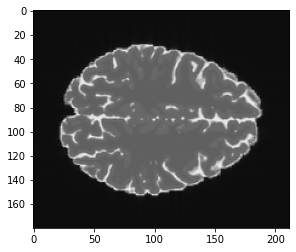

In [7]:
plt.imshow(n_snrgt[:,:,90],cmap='gray')

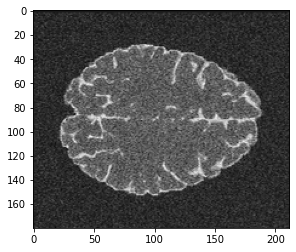

In [8]:
plt.imshow(n_snr20[:,:,90],cmap='gray')

In [9]:
mask_zoom = zoom(mask,(2,2,2))

In [10]:
mask_zoom[mask_zoom<0.5]=0
mask_zoom[mask_zoom>0.5]=1

In [11]:
n_snr20[mask_zoom==0] = 0.
n_snrgt[mask_zoom==0] = 0.

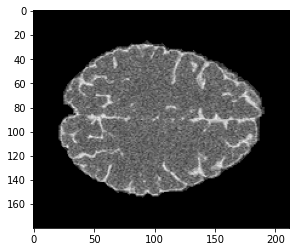

In [12]:
plt.imshow(n_snr20[:,:,90],cmap='gray')

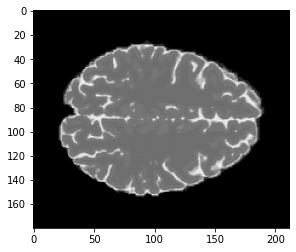

In [13]:
plt.imshow(n_snrgt[:,:,90],cmap='gray')

In [14]:
idx = 90
img_test = n_snr20[:,:,idx]
img_gt = n_snrgt[:,:,idx]

In [91]:
img_test

memmap([[-2.42797661, -2.42797661, -2.42797661, ..., -2.42797661,
         -2.42797661, -2.42797661],
        [-2.42797661, -2.42797661, -2.42797661, ..., -2.42797661,
         -2.42797661, -2.42797661],
        [-2.42797661, -2.42797661, -2.42797661, ..., -2.42797661,
         -2.42797661, -2.42797661],
        ...,
        [-2.42797661, -2.42797661, -2.42797661, ..., -2.42797661,
         -2.42797661, -2.42797661],
        [-2.42797661, -2.42797661, -2.42797661, ..., -2.42797661,
         -2.42797661, -2.42797661],
        [-2.42797661, -2.42797661, -2.42797661, ..., -2.42797661,
         -2.42797661, -2.42797661]])

In [95]:
img_gt


memmap([[-2.54906774, -2.54906774, -2.54906774, ..., -2.54906774,
         -2.54906774, -2.54906774],
        [-2.54906774, -2.54906774, -2.54906774, ..., -2.54906774,
         -2.54906774, -2.54906774],
        [-2.54906774, -2.54906774, -2.54906774, ..., -2.54906774,
         -2.54906774, -2.54906774],
        ...,
        [-2.54906774, -2.54906774, -2.54906774, ..., -2.54906774,
         -2.54906774, -2.54906774],
        [-2.54906774, -2.54906774, -2.54906774, ..., -2.54906774,
         -2.54906774, -2.54906774],
        [-2.54906774, -2.54906774, -2.54906774, ..., -2.54906774,
         -2.54906774, -2.54906774]])

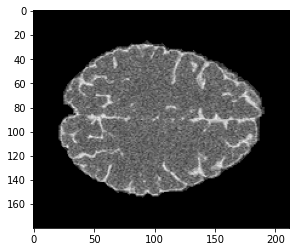

In [15]:
plt.imshow(img_test,cmap='gray')

In [16]:
score=ssim(img_test,img_gt)

In [17]:
score

0.7811013038387832

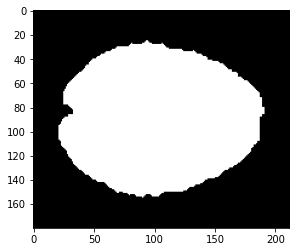

In [56]:
plt.imshow(mask_zoom[:,:,90],cmap='gray')

In [57]:
snr20[mask_zoom==0] = np.min(snr20)

In [58]:
idx = 90
img_mask = mask_zoom[:,:,idx]
img_test = snr20[:,:,idx]
img_gt = snrinfinite[:,:,idx]

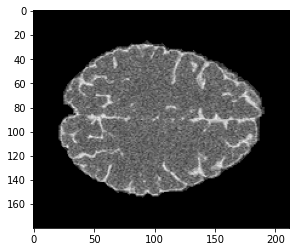

In [59]:
plt.imshow(img_test,cmap='gray')

In [43]:
ab = zoom(img_mask,(2,2))

In [44]:
np.unique(ab)

array([-0.22078902, -0.20003106, -0.19163046, ...,  1.21671966,
        1.21941819,  1.24529272])

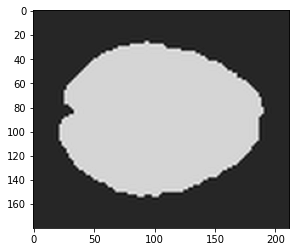

In [45]:
plt.imshow(ab,cmap='gray')

# preprocessing method

In [51]:
def normalize(snr20, snr40, snrinfinite):
  ma_20 = np.max(snr20)
  mi_20 = np.min(snr20)
  n_snr20 = 255*(snr20-mi_20)/(ma_20-mi_20)
  ma_40 = np.max(snr40)
  mi_40 = np.min(snr40)
  n_snr40 = 255*(snr40-mi_40)/(ma_40-mi_40)
  ma_gt = np.max(snrinfinite)
  mi_gt = np.min(snrinfinite)
  n_snrgt = 255*(snrinfinite-mi_gt)/(ma_gt-mi_gt)
  return n_snr20, n_snr40, snrinfinite

def mask_off(n_snr20, n_snr40, n_snrgt):
  mask_zoom = zoom(mask,(2,2,2))
  mask_zoom[mask_zoom<0.5]=0
  mask_zoom[mask_zoom>0.5]=1

  n_snr20[mask_zoom==0] = 0.
  n_snr40[mask_zoom==0] = 0.
  n_snrgt[mask_zoom==0] = 0.

  return n_snr20, n_snr40, n_snrgt

def img2pca(patch_size, image_2D):
  x_size, y_size = image_2D.shape
  pca=[]
  for i in range(x_size-patch_size+1):
    for j in range(y_size-patch_size+1):
      patch = []
      for z1 in range(patch_size):
        k=i+z1
        for z2 in range(patch_size):
          patch.append(image_2D[k,j+z2])

      pca.append(patch)                                                                 

  return np.array(pca)

def pca2img(image_size, pca):
  x_size, y_size = image_size
  patch_size, feature = pca.shape
  feature_size = int(math.sqrt(feature))
  img = np.zeros(image_size)
  img_weight = np.zeros(image_size)

  count_x = 0
  count_y = 0
  count = 0
  for i in range(patch_size):
    for k in range(feature_size):
      for j in range(feature_size):
        if count == feature_size*feature_size*(y_size-feature_size+1):
          count_x += 1
          count = 0
        count += 1
        if count_y == y_size-feature_size+1:
          count_y = 0
        img[k+count_x,j+count_y] += pca[i,k*feature_size+j]
        img_weight[k+count_x,j+count_y] +=1
    
    count_y += 1
  return img/img_weight    

def PCA_denoise(patch,k,img_in):

  pca_raw = img2pca(patch, img_in)
  
  img = pca_raw.copy() 

  pca = PCA(n_components = k)
  pca.fit(img)
  Z = pca.transform(img)

  pca_image = pca.inverse_transform(Z)  

  img_out = pca2img(img_in.shape, pca_image)

  return img_out

In [20]:
mask = nib.load(os.path.join(data_path, "mask.nii")).get_fdata()
snr20 = nib.load(os.path.join(data_path, "t2_snr20_b0space.nii")).get_fdata()
snr40 = nib.load(os.path.join(data_path, "t2_snr40_b0space.nii")).get_fdata()
snrinfinite = nib.load(os.path.join(data_path, "t2_snrinfinite_b0space.nii")).get_fdata()

In [71]:
n_snr20, n_snr40, snrinfinite = normalize(snr20, snr40, snrinfinite)
mo_snr20, mo_snr40, mo_snrgt = mask_off(n_snr20, n_snr40, n_snrgt)

In [64]:
def train_k(snr20, snr40, gt, patch_size, i):
  k_range = patch_size*patch_size
  score_20 = np.zeros(k_range)
  score_40 = np.zeros(k_range)
  img_gt = gt[:,:,i]
  img_20 = snr20[:,:,i]
  print()
  print("When patch_size={}, ssim={}, psnr={}".format(patch_size, ssim(img_20, img_gt), cv2.PSNR(img_20, img_gt)))
  for k in range(1,k_range):
      #img_40 = snr40[:,:,i]
      sim, snr = evaluate(patch_size, k, img_20, img_gt)
      print("k={}, ssim={}, psnr={}".format(k,sim,snr))
  print()

In [69]:
# implement 2D DCT
def dct2(a):
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

# implement 2D IDCT
def idct2(a):
    return idct(idct(a.T, norm='ortho').T, norm='ortho')
    
def Geometric_mean(Slice,windowSize):
    Slice = Slice+0.000001
    x,y = Slice.shape
    kernal_matrix = img2pca(windowSize, Slice)
    newSlice = np.zeros((x,y),)
    start_x = int((windowSize-1)/2)
    stop_x = int(x-(windowSize-1)/2)
    start_y = int((windowSize-1)/2)
    stop_y = int(y-(windowSize-1)/2)
    for i in range(start_x,stop_x):
        for j in range(start_y,stop_y):
            kernal = Slice[i-start_x:i+start_x+1,j-start_y:j+1+start_y]
            kernal_log = np.log(kernal)
            inside_log = np.sum(kernal_log)
            inside   = np.exp(inside_log)
            newSlice[i,j] = (inside)**(1/(windowSize)**2)
    
    return newSlice-0.000001

In [136]:
# implement 2D DCT
def dct2(a):
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

# implement 2D IDCT
def idct2(a):
    return idct(idct(a.T, norm='ortho').T, norm='ortho')

def DCT_Slice(patchSize, Slice,keepRow,keepCol):
    x,y = Slice.shape
    k = patchSize
    newx = np.ceil(x/k)*k
    newy = np.ceil(y/k)*k
    #if ((newx-x)%2) != 0:
    #    newx +=1
    #if ((newy-y)%2) != 0:
    #    newy +=1
    slice_new1 = np.zeros((int(newx),int(newy)))
    slice_new1[int((newx-x)/2):int(newx-(newx-x)/2),int((newy-y)/2):int(newy-(newy-y)/2)] = Slice
    dct_slice = slice_new1
    for i in range(int(np.floor(newx/k))):
        for j in range(int(np.floor(newy/k))):
            patch = slice_new1[i*k:(i+1)*k,j*k:(j+1)*k]
            patchDct = dct2(patch)
            patchDct[keepRow:k, keepCol:k] = 0
            newPatch = idct2(patchDct)
            dct_slice[i*k:(i+1)*k,j*k:(j+1)*k] = newPatch
    slice_dct = dct_slice[int((newx-x)/2):int(newx-(newx-x)/2),int((newy-y)/2):int(newy-(newy-y)/2)]
    return slice_dct

In [142]:
dct2(l)

TypeError: ignored

In [152]:
def trans(pca, keepRow, keepCol):
  patch_size, feature = pca.shape
  k = int(math.sqrt(feature))
  l=[]
  for i in range(patch_size):
    patch = np.reshape(pca[i], (k,k))
    patchDct = dct2(patch)
    patchDct[keepRow:k, keepCol:k] = 0
    newPatch = idct2(patchDct)
    newPatch = np.reshape(pca[i], feature)
    l.append(newPatch)
  return np.array(l)

In [ ]:
l=trans()

In [132]:
i=90
img_gt = mo_snrgt[:,:,i]
img_20 = mo_snr20[:,:,i]

In [158]:
pca_raw = img2pca(8, img_20)
l=trans(pca_raw,3,4)
img_out = pca2img(img_20.shape,l)

In [151]:
l

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

In [156]:
def dctt(gt,img,ps):
  for i in range(3,ps):
    pca_raw = img2pca(ps, img)
    l=trans(pca_raw,i,i)
    img_out = pca2img(img.shape,l)
    print("keep:{},ssim:{},psnr:{}".format(i,ssim(img_out, gt),cv2.PSNR(img_out, gt)))
    

In [157]:
i=dctt(img_gt, img_20, 8)

keep:3,ssim:0.7811013037673764,psnr:26.566239375627386
keep:4,ssim:0.7811013037673764,psnr:26.566239375627386
keep:5,ssim:0.7811013037673764,psnr:26.566239375627386
keep:6,ssim:0.7811013037673764,psnr:26.566239375627386
keep:7,ssim:0.7811013037673764,psnr:26.566239375627386


In [155]:
i

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [117]:
img_out = pca2img(img_20.shape,l)

In [82]:
img_out = Geometric_mean(img_20,4)

In [118]:
ssim(img_out, img_gt)

0.7811013037673764

In [119]:
cv2.PSNR(img_out, img_gt)

26.566239375627386

In [65]:
def evaluate(patch_size, k, img_in, gt):
  img_out = PCA_denoise(patch_size, k, img_in)
  return ssim(img_out, gt), cv2.PSNR(img_out, gt)

In [68]:
train_k(n_snr20, n_snr40, n_snrgt, 5, 90)

ssim=0.7811013038387832, psnr=26.566239375627386
k=1, ssim=0.5284225487295942, psnr=23.483395480875224
k=2, ssim=0.5838659617998948, psnr=24.944872531401504
k=3, ssim=0.6088994091215202, psnr=25.983024847947025
k=4, ssim=0.660008945578623, psnr=26.570383240339467
k=5, ssim=0.7100844351018315, psnr=27.127910845220065
k=6, ssim=0.7335136520752553, psnr=27.37521519103991
k=7, ssim=0.7420593617461968, psnr=27.597727368996292
k=8, ssim=0.7396307210139033, psnr=27.75266181425579
k=9, ssim=0.7379187390394097, psnr=27.800745066767576
k=10, ssim=0.7401394662906693, psnr=27.799395402571932
k=11, ssim=0.7420429474379939, psnr=27.749765210661323
k=12, ssim=0.7418843711603357, psnr=27.65617031798888
k=13, ssim=0.7394213602222491, psnr=27.62299520198541
k=14, ssim=0.7401117333794238, psnr=27.532796787958098
k=15, ssim=0.7375997447801192, psnr=27.450240221767142
k=16, ssim=0.736994279813997, psnr=27.305973265718535
k=17, ssim=0.7356380534067872, psnr=27.20480576125405
k=18, ssim=0.7364847060735543, p

In [ ]:
def evaluate_k(snr20, snr40, gt, patch_size):
  k_range = patch_size*patch_size
  score_20 = np.zeros(k_range)
  score_40 = np.zeros(k_range)
  for k in range(1,k_range):
    #for i in range(gt.shape[2]):
      print(k)
      i=90
      img_gt = gt[:,:,i]
      img_20 = snr20[:,:,i]
      img_40 = snr40[:,:,i]
      
      img_20_out = PCA_denoise(patch_size, k, img_20)
      img_40_out = PCA_denoise(patch_size, k, img_40)

      score_20[k] += cv2.PSNR(img_20_out, img_gt)
      score_40[k] += cv2.PSNR(img_40_out, img_gt)

  print("SNR = 20, when patch size = {}, k = {}, has best score".format(patch_size,np.argmax(score_20)))
  print("SNR = 40, when patch size = {}, k = {}, has best score".format(patch_size,np.argmax(score_20)))

  return np.max(score_20), np.argmax(score_20), np.max(score_40), np.argmax(score_40)

def evaluate_patch_size(snr20, snr40, gt, max_patch_size):
  best_20 = 0
  best_40 = 0
  best_patch_20 = 0
  best_patch_20 = 0
  best_k_20 = 0
  best_k_40 = 0

  for i in range(2,max_patch_size):
    max_20, k_20, max_40, k_40 = evaluate_k(snr20, snr40, gt, i)
    if best_20 < max_20:
      best_20 = max_20
      best_patch_20 = i
      best_k_20 = k_20
    if best_40 < max_40:
      best_40 = max_40
      best_patch_40 = i
      best_k_40 = k_40
  return best_patch_20, best_k_20, best_patch_40, best_k_40

In [59]:
max_20, k_20, max_40, k_40 = evaluate_k(n_snr20, n_snr40, n_snrgt, 9)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
SNR = 20, when patch size = 9, k = 31, has best score
SNR = 40, when patch size = 9, k = 31, has best score


In [60]:
max_20

27.717379770621893

In [56]:
max_20

27.800743598399542

In [54]:
cv2.PSNR(n_snr20[:,:,90], n_snrgt[:,:,90])

26.566239375627386

In [46]:
img_20_out = PCA_denoise(3, 6, n_snr20[:,:,90])

In [47]:
ssim(img_20_out, n_snrgt[:,:,90])

0.7568596290222889

In [48]:
ssim(n_snr20[:,:,90], n_snrgt[:,:,90])

0.7811013038387832

In [40]:
max_20

0.756859629098816

In [37]:
max_40

0.7956892951902294

In [ ]:
k_20

In [ ]:
k_40

In [ ]:
def pca2img2(image_size, pca):
  x_size, y_size = image_size
  patch_size, feature = pca.shape
  feature = int(math.sqrt(feature))
  img=[]
  pix=[]
  for i in range(patch_size): 
    pix.append(pca[i,0])
    if len(pix)==y_size-feature+1:
      for j in range(1,feature):
        pix.append(pca[i,j])
      img.append(pix)
      pix=[]

  for k in range(1,feature):
    for i in range(patch_size-y_size+feature-1,patch_size):
      pix.append(pca[i,feature*k])
      if len(pix)==y_size-feature+1:
        for j in range(1,feature):
          pix.append(pca[i,feature*k+j])
        img.append(pix)
        pix=[]

  return np.array(img)
  
def PCA_method(patch,k,img_in):


  pca_raw = img2pca(patch, img_in)

  X = pca_raw.copy()
  X -= np.mean(X, axis=0)

  U,s,Vh = np.linalg.svd(X)
  W = Vh[:k]

  Z = np.matmul(X,W.T)

  pca_image = np.matmul(Z,W)

  img_out = pca2img(img_in.shape, pca_image)

  return img_out

# mask off

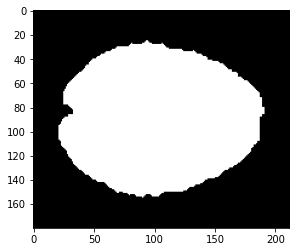

In [75]:
plt.imshow(img_mask,cmap='gray')

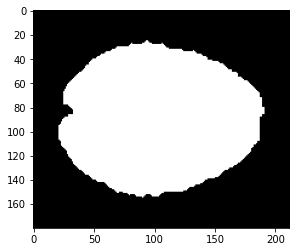

In [76]:
reshape_img_mask = reshape(img_mask, img_test.T.shape)
plt.imshow(reshape_img_mask,cmap='gray')

In [77]:
reshape_img_mask.shape

(180, 212)

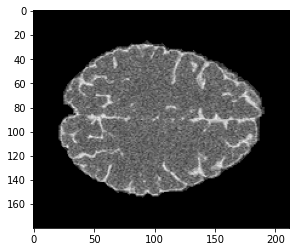

In [78]:
plt.imshow(img_test,cmap='gray')

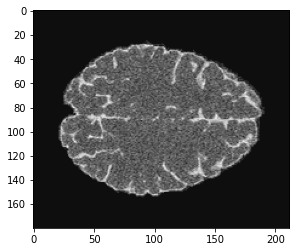

In [79]:
img_in = mask_off(img_test,reshape_img_mask)
plt.imshow(img_in,cmap='gray')

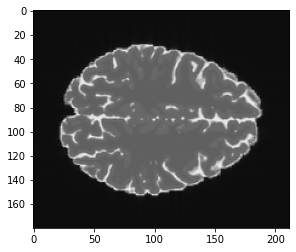

In [80]:
plt.imshow(img_gt,cmap='gray')

# denosie

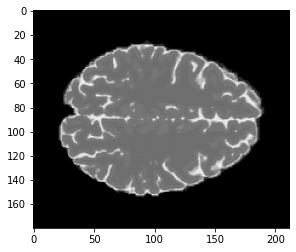

In [222]:
plt.imshow(img_gt,cmap='gray')

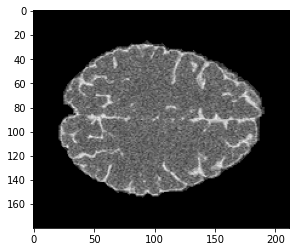

In [223]:
plt.imshow(img_test,cmap='gray')

In [245]:
np.max(img_test)

230.31598684982285

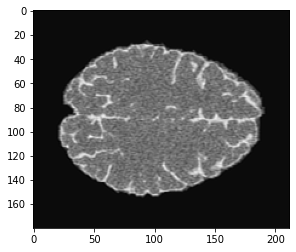

In [252]:
img_out = PCA_denoise(3, 5, img_test)
plt.imshow(img_out,cmap='gray')

In [251]:
np.max(img_out)

230.31598684982288

In [248]:
np.min(img_out)

-44.545970523515855

In [253]:
ssim_noise = compare_ssim(img_gt, img_gt,full=True)

In [254]:
ssim_noise[0]

1.0

In [255]:
ssim_noise = compare_ssim(img_test, img_gt,full=True)

In [256]:
ssim_noise[0]

0.7811013038387832

In [257]:
ssim_noise = compare_ssim(img_out, img_test ,full=True)

In [258]:
ssim_noise[0]

0.9195089436705628

In [260]:
cv2.PSNR(img_test, img_gt)

26.566239375627386

In [261]:
cv2.PSNR(img_out, img_gt)

27.61302690510471

# reshape denoise

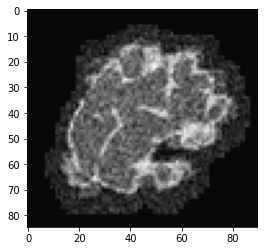

In [ ]:
img_in_reshape = img_in[55:140,20:110]
plt.imshow(img_in_reshape,cmap='gray')

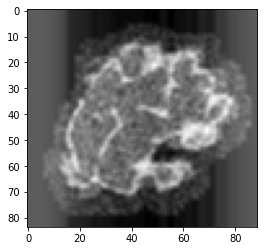

In [ ]:
img_out_reshape = PCA_denoise(2, 1, img_in_reshape)
plt.imshow(img_out_reshape,cmap='gray')

# debugg

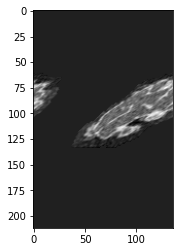

In [ ]:
new_img_out = np.resize(img_out,img_test.shape)
plt.imshow(new_img_out,cmap='gray')

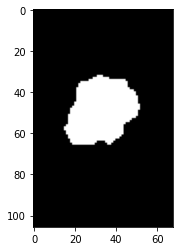

In [ ]:
plt.imshow(img_mask,cmap='gray')

In [ ]:
test_arr=[[[0,0],[0,1],[0,2],[0,3],[0,4],[0,5]],[[1,0],[1,1],[1,2],[1,3],[1,4],[1,5]],[[2,0],[2,1],[2,2],[2,3],[2,4],[2,5]],[[3,1],[3,2],[3,3],[3,4],[3,5],[3,6]]]


In [ ]:
test_arr=[[1,2,3,4,5,6],[7,8,9,10,11,12],[13,14,15,16,17,18],[19,20,21,22,23,24]]
test_arr=np.array(test_arr)
test_arr

array([[ 1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18],
       [19, 20, 21, 22, 23, 24]])

In [ ]:
l=img2pca(3,test_arr)
l

array([[ 1,  2,  3,  7,  8,  9, 13, 14, 15],
       [ 2,  3,  4,  8,  9, 10, 14, 15, 16],
       [ 3,  4,  5,  9, 10, 11, 15, 16, 17],
       [ 4,  5,  6, 10, 11, 12, 16, 17, 18],
       [ 7,  8,  9, 13, 14, 15, 19, 20, 21],
       [ 8,  9, 10, 14, 15, 16, 20, 21, 22],
       [ 9, 10, 11, 15, 16, 17, 21, 22, 23],
       [10, 11, 12, 16, 17, 18, 22, 23, 24]])

In [ ]:
def pca2img2(image_size, pca):
  x_size, y_size = image_size
  patch_size, feature = pca.shape
  feature_size = int(math.sqrt(feature))
  img = np.zeros(image_size)
  img_weight = np.zeros(image_size)

  count_x = 0
  count_y = 0
  count = 0
  for i in range(patch_size):
    print("patch:{}".format(i))
    for k in range(feature_size):
      for j in range(feature_size):
        if count == feature_size*feature_size*(y_size-feature_size+1):
          count_x += 1
          count = 0
        count += 1
        if count_y == y_size-feature_size+1:
          count_y = 0
        #print("pca x={}, y={};img x={},y={}".format(i,k*feature_size+j,k+count_x,j+count_y))
        print("c:{},c_X:{},k:{},{}".format(count,count_x,k,k+count_x))
        img[k+count_x,j+count_y] += pca[i,k*feature_size+j]
        img_weight[k+count_x,j+count_y] +=1
    
    count_y += 1
  return img/img_weight    

In [ ]:
img=pca2img2(test_arr.shape,l)

patch:0
c:1,c_X:0,k:0,0
c:2,c_X:0,k:0,0
c:3,c_X:0,k:0,0
c:4,c_X:0,k:1,1
c:5,c_X:0,k:1,1
c:6,c_X:0,k:1,1
c:7,c_X:0,k:2,2
c:8,c_X:0,k:2,2
c:9,c_X:0,k:2,2
patch:1
c:10,c_X:0,k:0,0
c:11,c_X:0,k:0,0
c:12,c_X:0,k:0,0
c:13,c_X:0,k:1,1
c:14,c_X:0,k:1,1
c:15,c_X:0,k:1,1
c:16,c_X:0,k:2,2
c:17,c_X:0,k:2,2
c:18,c_X:0,k:2,2
patch:2
c:19,c_X:0,k:0,0
c:20,c_X:0,k:0,0
c:21,c_X:0,k:0,0
c:22,c_X:0,k:1,1
c:23,c_X:0,k:1,1
c:24,c_X:0,k:1,1
c:25,c_X:0,k:2,2
c:26,c_X:0,k:2,2
c:27,c_X:0,k:2,2
patch:3
c:28,c_X:0,k:0,0
c:29,c_X:0,k:0,0
c:30,c_X:0,k:0,0
c:31,c_X:0,k:1,1
c:32,c_X:0,k:1,1
c:33,c_X:0,k:1,1
c:34,c_X:0,k:2,2
c:35,c_X:0,k:2,2
c:36,c_X:0,k:2,2
patch:4
c:1,c_X:1,k:0,1
c:2,c_X:1,k:0,1
c:3,c_X:1,k:0,1
c:4,c_X:1,k:1,2
c:5,c_X:1,k:1,2
c:6,c_X:1,k:1,2
c:7,c_X:1,k:2,3
c:8,c_X:1,k:2,3
c:9,c_X:1,k:2,3
patch:5
c:10,c_X:1,k:0,1
c:11,c_X:1,k:0,1
c:12,c_X:1,k:0,1
c:13,c_X:1,k:1,2
c:14,c_X:1,k:1,2
c:15,c_X:1,k:1,2
c:16,c_X:1,k:2,3
c:17,c_X:1,k:2,3
c:18,c_X:1,k:2,3
patch:6
c:19,c_X:1,k:0,1
c:20,c_X:1,k:0,1
c:21,c_X:1

In [ ]:
img

array([[ 1.,  2.,  3.,  4.,  5.,  6.],
       [ 7.,  8.,  9., 10., 11., 12.],
       [13., 14., 15., 16., 17., 18.],
       [19., 20., 21., 22., 23., 24.]])

In [ ]:
img_weight

array([[1., 2., 3., 3., 2., 1.],
       [2., 4., 6., 6., 4., 2.],
       [2., 4., 6., 6., 4., 2.],
       [1., 2., 3., 3., 2., 1.]])

In [ ]:
img/img_weight

array([[ 1.,  2.,  3.,  4.,  5.,  6.],
       [ 7.,  8.,  9., 10., 11., 12.],
       [13., 14., 15., 16., 17., 18.],
       [19., 20., 21., 22., 23., 24.]])

In [ ]:
m=pca2img(test_arr.shape,l)
m

array([[ 1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18],
       [19, 20, 21, 22, 23, 24]])

In [ ]:
np.array_equal(test_arr, m)

True

In [ ]:
img = img_test.copy() 
img -= np.mean(img, axis=0) 

In [ ]:
img.shape

(212, 136)

In [ ]:
i=5
pca_raw=img2pca(i,img_test)
t_img=pca2img(img.shape,pca_raw)
np.array_equal(img, t_img)

True

In [ ]:
img_test

In [ ]:
pca_raw.shape

(27456, 25)

In [ ]:
pca = PCA(n_components=9)
pca.fit(pca_raw)

PCA(n_components=9)

In [ ]:
pca1 = pca.transform(pca_raw)

In [ ]:
pca2 = pca.components_

In [ ]:
img.shape

(212, 136)

In [ ]:
pca1.shape

(27456, 9)

In [ ]:
img=pca2img(img.shape,np.matmul(pca1,pca2))

In [ ]:
np.matmul(pca1,pca2).shape

(27456, 25)

In [ ]:
img=pca2img((210,134),pca)

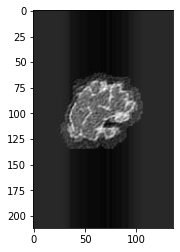

In [ ]:
plt.imshow(img,cmap='gray')